# 02. EDA — 세그먼트 단위 파형 유형 파악

## 배경
`01_eda.ipynb`에서 정리된 상황: 정상/이상은 파일 단위 라벨뿐이고(사이클 단위 정답 없음),
사이클 단위로 봐도 이상이 상시가 아니라 간헐적이며(오경보 0 임계에서도 17개 중 3개 미탐지),
정상 쪽도 시간에 따라 흔들린다(4분할 Q1→Q4에서 RMS 40% 하락). 이걸 "파일 단위로 다르다"가
아니라 **세그먼트 단위로 유형이 섞여 있다**로 다시 보자는 게 이번 노트북의 출발점이다.

## 확인할 것 네 가지
1. **normal 내부에 운전 국면(레짐)이 있는가, 몇 개인가?** — 아니면 그냥 사이클 간 잡음(jitter)인가?
2. **outlier 내부에서 "명백히 이상 / 경계선 / 정상과 구분 안 됨"이 실제로 나뉘는가?**
3. **outlier의 이상 정도가 시간순으로 악화되는 궤적인가?** (초기결함 진행 가설)
4. **전류(AI2_Current) 파형의 "모양"도 정상/이상을 구분하는가?** (사용자 관찰: 정상은 깨끗한
   사인파, 이상은 파형이 깨져 있다 — 그리고 진동 진폭과 비례하는 것 같다)

## 0. 설정 및 로드

`01_eda.ipynb`와 동일한 정의(경로, 세그먼트 복원 로직)를 그대로 가져온다. 노트북 간
의존성을 만들지 않기 위해 의도적으로 각 노트북을 독립적으로 구성한다(01과 동일 관례).

In [1]:
import os, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]:
    if _f in _avail:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})

DATA_DIR = Path(os.environ.get("KAMP_DATA_DIR", "/mnt/d/data/kamp_ai/press_anomaly_dataset"))
SIGNALS  = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
FS, GAP_THR = 10.0, 0.15
MIN_N    = 10      # 01_eda 섹션 7과 동일: 1초 미만 세그먼트는 통계가 불안정해 제외
COLOR    = {"normal": "#1f77b4", "outlier": "#d62728"}

normal  = pd.read_csv(DATA_DIR / "press_data_normal.csv", index_col=0, parse_dates=["TimeStamp"])
outlier = pd.read_csv(DATA_DIR / "outlier_data.csv",      index_col=0, parse_dates=["TimeStamp"])
DFS = {"normal": normal, "outlier": outlier}

def make_segments(df):
    d = df["TimeStamp"].diff().dt.total_seconds()
    out = df.copy(); out["seg_id"] = (d > GAP_THR).cumsum().values
    return out

def seg_features(sdf, label):
    rows = []
    for sid, g in sdf.groupby("seg_id"):
        r = {"seg_id": sid, "label": label, "n": len(g), "t_start": g.TimeStamp.iloc[0]}
        for c in SIGNALS:
            x, s = g[c].values, g[c]
            r[f"{c}_rms"]  = float(np.sqrt((x ** 2).mean()))
            r[f"{c}_ac1"]  = float(s.autocorr(1))
            r[f"{c}_kurt"] = float(s.kurt())
        rows.append(r)
    return pd.DataFrame(rows)

SEG = {k: make_segments(df) for k, df in DFS.items()}
F   = pd.concat([seg_features(SEG[k], k) for k in DFS], ignore_index=True)
F   = F[F.n >= MIN_N].reset_index(drop=True)
Fn  = F[F.label == "normal"].sort_values("t_start").reset_index(drop=True)
Fo  = F[F.label == "outlier"].sort_values("t_start").reset_index(drop=True)

print(f"normal 세그먼트(n>={MIN_N}): {len(Fn)}개  |  outlier 세그먼트(n>={MIN_N}): {len(Fo)}개")

normal 세그먼트(n>=10): 530개  |  outlier 세그먼트(n>=10): 17개


## 1. normal 내부 국면(레짐) 탐색 — 모양부터 본다

의도: 분류/군집을 돌리기 전에, 시간에 따라 값이 어떻게 움직이는지 **눈으로 먼저** 본다.
사이클별 값은 잡음이 커서 점만 찍으면 패턴이 안 보이므로, 10분 rolling 평균을 같이 그려
"천천히 변하는 성분"만 따로 드러낸다.

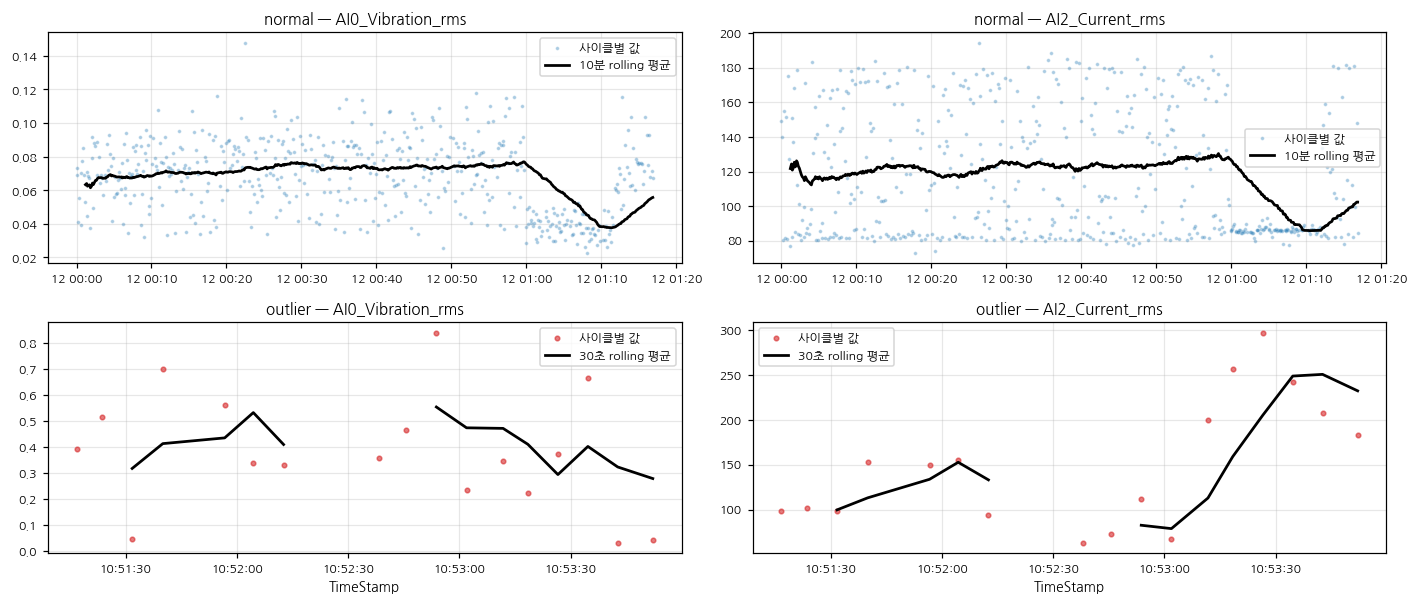

In [2]:
roll_n = Fn.set_index("t_start")[["AI0_Vibration_rms", "AI2_Current_rms"]].rolling("600s", min_periods=10).mean()
roll_o = Fo.set_index("t_start")[["AI0_Vibration_rms", "AI2_Current_rms"]].rolling("30s", min_periods=3).mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 5.6))
for col, c in enumerate(["AI0_Vibration_rms", "AI2_Current_rms"]):
    axes[0, col].plot(Fn.t_start, Fn[c], ".", ms=3, alpha=.25, color=COLOR["normal"], label="사이클별 값")
    axes[0, col].plot(roll_n.index, roll_n[c], color="black", lw=1.8, label="10분 rolling 평균")
    axes[0, col].set_title(f"normal — {c}"); axes[0, col].legend()

    axes[1, col].plot(Fo.t_start, Fo[c], ".", ms=6, alpha=.6, color=COLOR["outlier"], label="사이클별 값")
    axes[1, col].plot(roll_o.index, roll_o[c], color="black", lw=1.8, label="30초 rolling 평균")
    axes[1, col].set_title(f"outlier — {c}"); axes[1, col].set_xlabel("TimeStamp"); axes[1, col].legend()
plt.tight_layout(); plt.show()

**결과:** 사이클별 값(파란 점)은 산만하게 흩어져 있지만, rolling 평균(검은 선)을 보면
**AI0_Vibration_rms와 AI2_Current_rms가 거의 같은 모양으로 움직인다** — 00:00~01:00까지는
평탄(AI0 ≈ 0.07)하다가, **01:00부터 뚜렷하게 떨어져서 01:10 근처에서 최저점(AI0 ≈ 0.04)을
찍고, 파일이 끝나는 01:17까지 다시 올라온다.** 서로 독립된 두 센서(진동·전류)가 같은 시점에
같은 모양으로 움직인다는 건 잡음이 아니라 **실제 운전조건 변화**라는 뜻이다(예: 마지막
15분 구간에 생산량 감소·품목 교체·휴식 같은 실제 이벤트가 있었을 가능성). 01_eda에서
"Q4에서 40% 하락"이라 본 것은 사실 이 국지적인 V자 구간의 일부였다.

의도: 요약값(rolling 평균)만 보면 "01:00부터 조건이 바뀌었다"까지만 알 수 있다.
실제로 파형이 어떻게 달라지는지 3개 세그먼트(전환 전 00:30 / V자 최저점 01:10 / 회복
구간 01:16)를 직접 겹쳐 보고 확인한다.

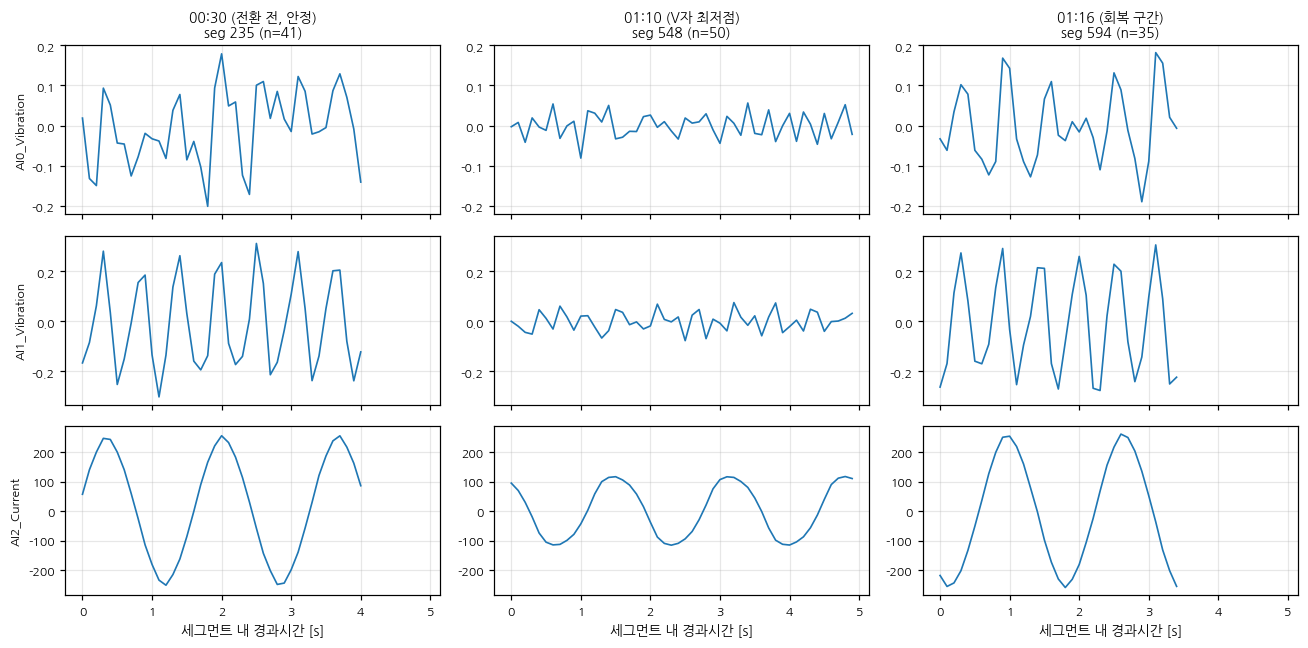

In [3]:
picks = [("00:30 (전환 전, 안정)", 235), ("01:10 (V자 최저점)", 548), ("01:16 (회복 구간)", 594)]
fig, axes = plt.subplots(3, len(picks), figsize=(4*len(picks), 6), sharex=True)
for j, (label, sid) in enumerate(picks):
    s = SEG["normal"][SEG["normal"].seg_id == sid].copy()
    s["t_in_seg"] = np.arange(len(s)) / FS
    for i, c in enumerate(SIGNALS):
        axes[i, j].plot(s.t_in_seg, s[c], lw=1.1, color=COLOR["normal"])
        if j == 0: axes[i, j].set_ylabel(c, fontsize=8)
    axes[0, j].set_title(f"{label}\nseg {sid} (n={len(s)})", fontsize=9)
    axes[-1, j].set_xlabel("세그먼트 내 경과시간 [s]")
for i in range(3):
    lo = min(ax.get_ylim()[0] for ax in axes[i]); hi = max(ax.get_ylim()[1] for ax in axes[i])
    for ax in axes[i]: ax.set_ylim(lo, hi)
plt.tight_layout(); plt.show()

**결과:** V자 최저점(01:10, 가운데)에서 `AI0_Vibration`·`AI1_Vibration` 진폭이
눈에 띄게 작아지고, `AI2_Current`의 사인파(에일리어싱) 진폭도 ±250 → ±120 수준으로
줄어든다. 전환 전(00:30)과 회복 구간(01:16)은 서로 거의 비슷한 모양으로 돌아온다.
세 채널이 동시에 같이 작아진다는 게, 이게 랜덤한 사이클 잡음이 아니라 **실제 부하가
줄어든 운전조건 변화**라는 걸 파형 수준에서도 확인해준다.

의도: V자 딥 구간(01:00~01:17)은 진폭만 줄어든 것인지, 사인파의 정체(주기·모양) 자체가
달라진 것인지 확인한다. 딥 구간에도 같은 주기·같은 순수도가 재현된다면 "같은 파형이 약해진
것"이고, 아니라면 별개의 파형(레짐)으로 다뤄야 한다.

In [16]:
def dominant_period(x, fs=FS):
    n = len(x); x = np.asarray(x, float) - np.mean(x)
    P = np.abs(np.fft.rfft(x)) ** 2
    freqs = np.fft.rfftfreq(n, d=1/fs)
    k = np.argmax(P[1:]) + 1
    return 1 / freqs[k] if freqs[k] > 0 else np.inf

def band_purity(x, fs=FS, fmin=1/2.2, fmax=1/0.9):
    # normal에서 관측되는 실제 주기대(0.9~2.2s)로 탐색을 제한한 순수도 -- 램프를 사인으로 오인하는 것을 방지
    n = len(x); x = np.asarray(x, float) - np.mean(x)
    F = np.fft.rfft(x); freqs = np.fft.rfftfreq(n, d=1/fs)
    P = np.abs(F) ** 2
    band = (freqs >= fmin) & (freqs <= fmax)
    tot = P[1:].sum()
    return P[band].max() / tot if tot > 0 and band.any() else 0.0

rows = []
for sid, g in SEG["normal"].groupby("seg_id"):
    if len(g) < MIN_N: continue
    x = g["AI2_Current"].values
    rows.append({"seg_id": sid, "n": len(g), "t_start": g.TimeStamp.iloc[0],
                 "period": dominant_period(x), "purity": band_purity(x),
                 "cur_p2p": float(x.max() - x.min())})
Fp = pd.DataFrame(rows).sort_values("t_start").reset_index(drop=True)

dip = (Fp.t_start >= pd.Timestamp("2022-07-12 01:00:00")) & (Fp.t_start <= pd.Timestamp("2022-07-12 01:17:00"))
print(f"딥 구간(01:00~01:17) 세그먼트 {dip.sum()}개 / 전체 {len(Fp)}개\n")

comp = pd.DataFrame({
    "딥 밖":  [Fp[~dip].period.median(), Fp[~dip].purity.median(), Fp[~dip].cur_p2p.median()],
    "딥 안":  [Fp[dip].period.median(),  Fp[dip].purity.median(),  Fp[dip].cur_p2p.median()],
}, index=["period 중앙값[s]", "purity 중앙값", "cur_p2p 중앙값"])
display(comp.round(3))

q = pd.qcut(Fp.t_start.rank(method="first"), 8, labels=False)
print("시간 8분할 period 중앙값 (전 구간 동일해야 '같은 파형'):")
print(Fp.groupby(q).period.median().round(3).tolist())
print("시간 8분할 purity 중앙값:")
print(Fp.groupby(q).purity.median().round(3).tolist())

딥 구간(01:00~01:17) 세그먼트 115개 / 전체 530개



,딥 밖,딥 안
period 중앙값[s],1.667,1.667
purity 중앙값,0.979,0.944
cur_p2p 중앙값,339.416,232.344


시간 8분할 period 중앙값 (전 구간 동일해야 '같은 파형'):
[1.667, 1.667, 1.667, 1.667, 1.667, 1.667, 1.667, 1.667]
시간 8분할 purity 중앙값:
[0.995, 0.984, 0.958, 0.981, 0.979, 0.954, 0.941, 0.965]


**결과:** 딥 구간에서도 `period` 중앙값이 딥 밖과 **정확히 같다(1.667초)** — 시간을 8분할해도
모든 구간에서 동일하다. `purity`도 딥 구간에서 0.944로 딥 밖(0.979)보다 약간 낮을 뿐 여전히
높은 수준이다. 반면 `cur_p2p`(진폭)는 339 → 232로 확실히 줄어든다.

→ **딥 구간은 새로운 파형이 아니라, 같은 사인파(같은 주기·같은 순수도)가 진폭만 작아진
것이다.** normal을 하나의 파형 정체성으로 보는 게 타당하고, 딥 구간을 위해 별도 기준선을
나눌 필요는 없다는 뜻 — 섹션 2("이산적 국면 없음")의 결론과 일치한다.

## 2. normal 내부 국면 탐색 — 군집으로 정량 확인

의도: 위에서 본 "느린 변화"가 **몇 개의 구분되는 국면(레짐)** 으로 나뉘는지, 아니면 그냥
연속적인 흔들림인지 K-means로 확인한다. 국면이 진짜로 존재한다면 각 군집이 특정 시간대에
몰려 있어야 한다 — 군집이 시간에 걸쳐 뒤섞여 있다면 그건 국면이 아니라 사이클 간 잡음이다.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feat_cols = ["AI0_Vibration_rms", "AI0_Vibration_ac1", "AI1_Vibration_rms", "AI2_Current_rms"]
X = StandardScaler().fit_transform(Fn[feat_cols])

sil_rows = []
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
    sil_rows.append({"k": k, "silhouette": round(silhouette_score(X, km.labels_), 3),
                      "cluster_sizes": np.bincount(km.labels_).tolist()})
display(pd.DataFrame(sil_rows))

k = 2
km = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X)
Fn["cluster"] = km.labels_
Fn["t_rank"]  = Fn.t_start.rank(pct=True)   # 0~1로 정규화한 시간순 위치

print(f"k={k} 클러스터별 시간순 위치(t_rank, 0=처음~1=끝) 분포:")
display(Fn.groupby("cluster").t_rank.describe()[["mean", "min", "25%", "50%", "75%", "max"]].round(3))
print("시간순 cluster 시퀀스(앞 40개):", Fn.cluster.values[:40].tolist())

,k,silhouette,cluster_sizes
0,2,0.484,"[199, 331]"
1,3,0.403,"[175, 226, 129]"
2,4,0.417,"[170, 96, 129, 135]"
3,5,0.374,"[91, 140, 93, 128, 78]"


k=2 클러스터별 시간순 위치(t_rank, 0=처음~1=끝) 분포:


,mean,min,25%,50%,75%,max
cluster,,,,,,
0,0.436,0.002,0.221,0.436,0.641,0.998
1,0.540,0.006,0.271,0.558,0.822,1.000


시간순 cluster 시퀀스(앞 40개): [0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1]


**결과:** silhouette이 k=2에서 0.484로 가장 높지만, 0.5를 넘지 못해 군집 구조 자체가
강하지 않다. 더 결정적인 건 시간 분포다 — 두 클러스터 모두 `t_rank`가 0.00~1.00 전체에
걸쳐 있고 평균도 0.44/0.54로 비슷하다. 시퀀스를 봐도 `[0,0,1,0,1,0,1,...]`처럼
초반부터 두 군집이 섞여서 번갈아 나타난다. **즉 이 군집은 "시간대별 국면"이 아니라
"사이클마다 흔들리는 진폭 레벨"을 나눈 것뿐이다.**

→ 1번(시각화)과 2번(군집)을 같이 보면 결론이 명확해진다: **normal에는 이산적인 운전
국면(레짐)이 없다.** 대신 (a) 사이클 간 잡음이 크고, (b) 그 잡음 위에 마지막 15분 구간의
실제 V자 변화가 얹혀 있다. 국면별 기준선을 나눌 필요는 없지만, **고정된 단일 기준선도
위험하다** — 마지막 15분처럼 실제 운전조건이 바뀌는 구간에서는 오경보가 늘어날 수 있다.
rolling/EWMA 기준선을 쓰는 근거가 된다.

## 3. outlier 내부 유형 분류

의도: "이상 파일 = 이상 패턴 하나"가 아니라는 걸 01_eda에서 이미 확인했다(오경보 0에서도
3개 미탐지). 여기서는 17개 세그먼트 전체를 정상 분포 기준으로 3단계로 나눠 직접 본다.
경계는 `AI0_Vibration_rms` 기준 정상 최댓값(≈0.148)을 1배로 놓고: **1배 이하 = 정상과
구분 안 됨, 1~2배 = 경계선, 2배 초과 = 명백히 이상**으로 정의한다(임의 기준이므로
숫자 자체보다 "세 그룹이 실제로 갈리는가"를 보는 데 의미가 있다).

,seg_id,n,t_start,AI0_Vibration_rms,AI0_Vibration_ac1,tier
0,1,50,2022-07-17 10:51:16.724,0.391256,0.671254,명백히 이상
1,2,47,2022-07-17 10:51:23.615,0.515215,0.726976,명백히 이상
2,3,31,2022-07-17 10:51:31.734,0.045827,0.061376,정상과 구분안됨
3,4,18,2022-07-17 10:51:39.999,0.699241,0.715455,명백히 이상
4,6,50,2022-07-17 10:51:56.684,0.559658,0.766614,명백히 이상
5,7,40,2022-07-17 10:52:04.407,0.337417,0.734262,명백히 이상
6,8,25,2022-07-17 10:52:12.567,0.331365,0.795497,명백히 이상
7,11,50,2022-07-17 10:52:38.172,0.356109,0.755657,명백히 이상
8,12,42,2022-07-17 10:52:45.655,0.466278,0.693563,명백히 이상
9,13,28,2022-07-17 10:52:53.769,0.838542,0.729654,명백히 이상


tier 분포: {'명백히 이상': 12, '정상과 구분안됨': 3, '경계선': 2}


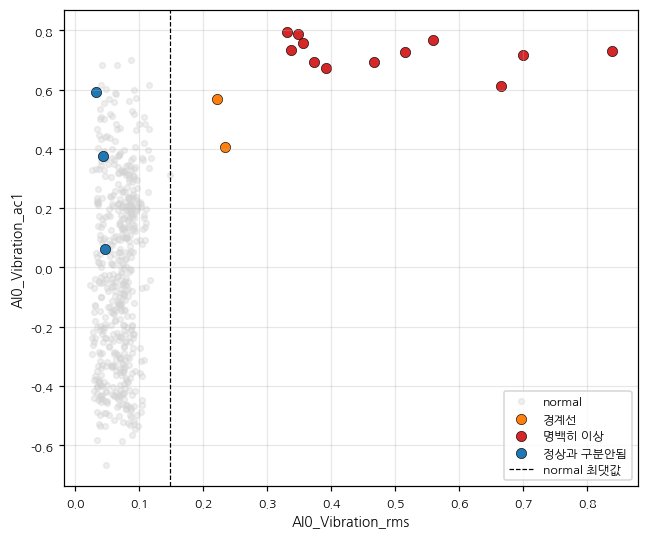

In [5]:
KEY, KEY2 = "AI0_Vibration_rms", "AI0_Vibration_ac1"
nmax = Fn[KEY].max()

def tier(v):
    if v <= nmax:      return "정상과 구분안됨"
    if v <= nmax * 2:  return "경계선"
    return "명백히 이상"

Fo["tier"] = Fo[KEY].apply(tier)
tier_color = {"정상과 구분안됨": "#1f77b4", "경계선": "#ff7f0e", "명백히 이상": "#d62728"}

display(Fo[["seg_id", "n", "t_start", KEY, KEY2, "tier"]])
print("tier 분포:", Fo.tier.value_counts().to_dict())

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Fn[KEY], Fn[KEY2], s=14, alpha=.35, color="lightgray", label="normal")
for tname, sub in Fo.groupby("tier"):
    ax.scatter(sub[KEY], sub[KEY2], s=45, color=tier_color[tname], label=tname,
               edgecolor="k", linewidth=.4)
ax.axvline(nmax, color="k", ls="--", lw=.8, label="normal 최댓값")
ax.set_xlabel(KEY); ax.set_ylabel(KEY2); ax.legend()
plt.tight_layout(); plt.show()

**결과:** 17개 중 **명백히 이상 12개, 경계선 2개, 정상과 구분안됨 3개**로 뚜렷하게
나뉜다. "정상과 구분안됨" 3개(seg 3, 19, 20)는 01_eda 섹션 7에서 찾은 미탐지 세그먼트와
**정확히 일치**한다 — 다른 접근(정상 분포 기준 tier 분류)으로도 같은 결론이 나온 것으로,
그 미탐지가 우연이 아니라는 교차검증이 된다.

산점도를 보면 흥미로운 지점이 하나 있다 — "정상과 구분안됨"(파란 점) 3개 중 2개는
`AI0_Vibration_ac1`(주기성)이 0.37~0.59로 normal 최댓값(0.70)에는 못 미치지만 normal
분포의 위쪽 꼬리 정도는 된다. 즉 **진폭만으로는 완전히 숨어 있어도 주기성 쪽에는 약한
흔적이 남아 있는 경우가 있다** — 다만 01_eda 7-1에서 이미 봤듯 `ac1` 단독은 정상 쪽에도
튀는 값이 많아 오경보 없이 이 흔적만으로 잡기는 어렵다. 두 피처를 **같이** 보는 게
왜 필요한지를 보여주는 사례다.

의도: tier 분류(명백히 이상 / 경계선 / 정상과 구분안됨)가 숫자상으로는 나뉘어도
실제 파형이 어떻게 다른지 직접 봐야 "확실히 이상한 조짐"이 무엇인지 구체적으로 알 수 있다.
먼저 normal 자체의 자연스러운 변동 범위를 보고(다음 셀), 그다음 outlier tier들만 따로
모아서(그 다음 셀) 비교한다 — 같은 그림에 섞으면 "정상의 흔들림"과 "이상의 흔들림"을
헷갈리기 쉬워서 둘을 나눈다.

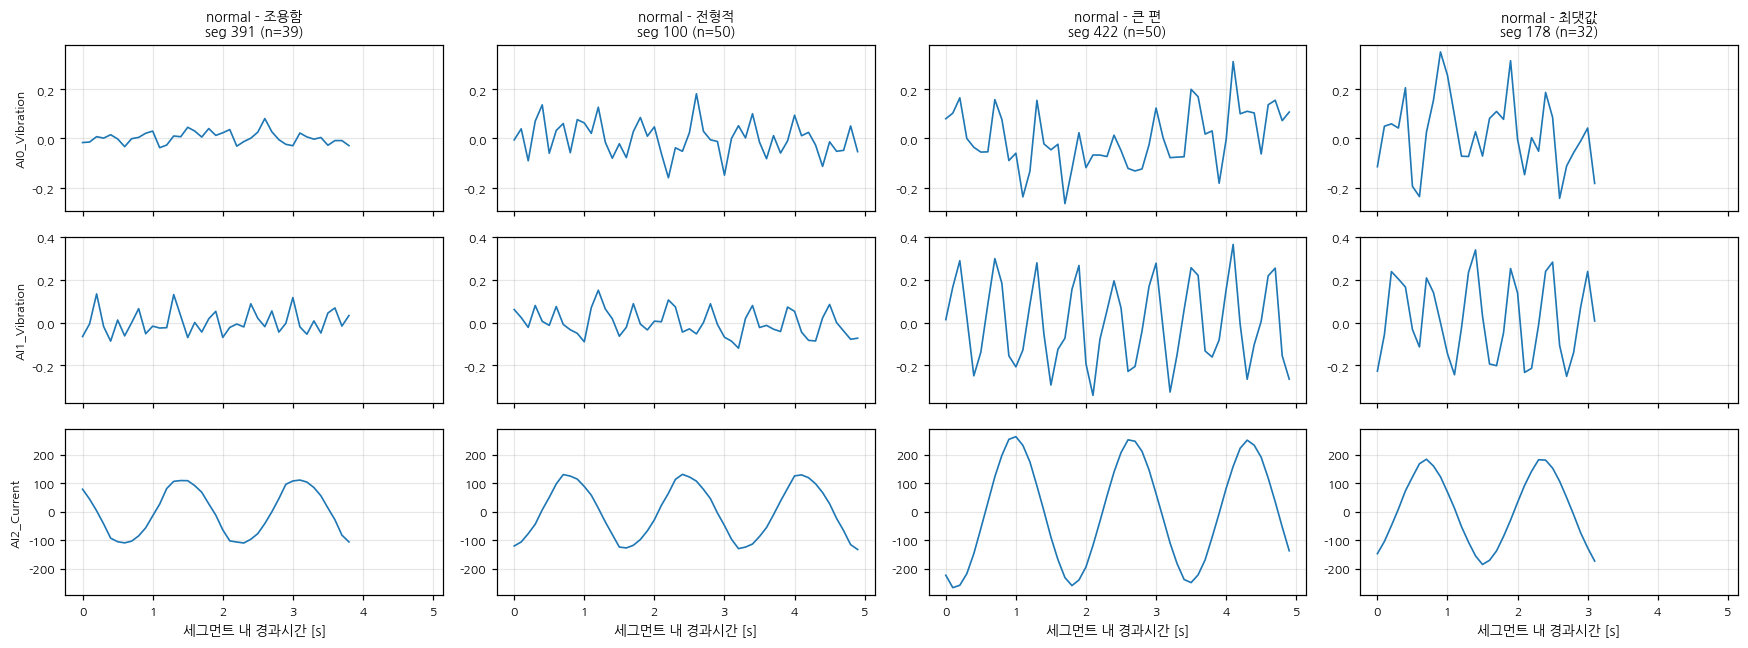

In [6]:
def plot_waves(picks):
    fig, axes = plt.subplots(3, len(picks), figsize=(4*len(picks), 6), sharex=True)
    for j, (label, k, sid) in enumerate(picks):
        s = SEG[k][SEG[k].seg_id == sid].copy()
        s["t_in_seg"] = np.arange(len(s)) / FS
        for i, c in enumerate(SIGNALS):
            axes[i, j].plot(s.t_in_seg, s[c], lw=1.1, color=COLOR[k])
            if j == 0: axes[i, j].set_ylabel(c, fontsize=8)
        axes[0, j].set_title(f"{label}\nseg {sid} (n={len(s)})", fontsize=9)
        axes[-1, j].set_xlabel("세그먼트 내 경과시간 [s]")
    for i in range(3):
        lo = min(ax.get_ylim()[0] for ax in axes[i]); hi = max(ax.get_ylim()[1] for ax in axes[i])
        for ax in axes[i]: ax.set_ylim(lo, hi)
    plt.tight_layout(); plt.show()

# normal만 모아서 — 조용함 -> 전형적 -> 큰 편 -> normal 안에서의 최댓값(=이후 tier 기준선)
picks_normal = [("normal - 조용함", "normal", 391), ("normal - 전형적", "normal", 100),
                ("normal - 큰 편",  "normal", 422), ("normal - 최댓값",  "normal", 178)]
plot_waves(picks_normal)

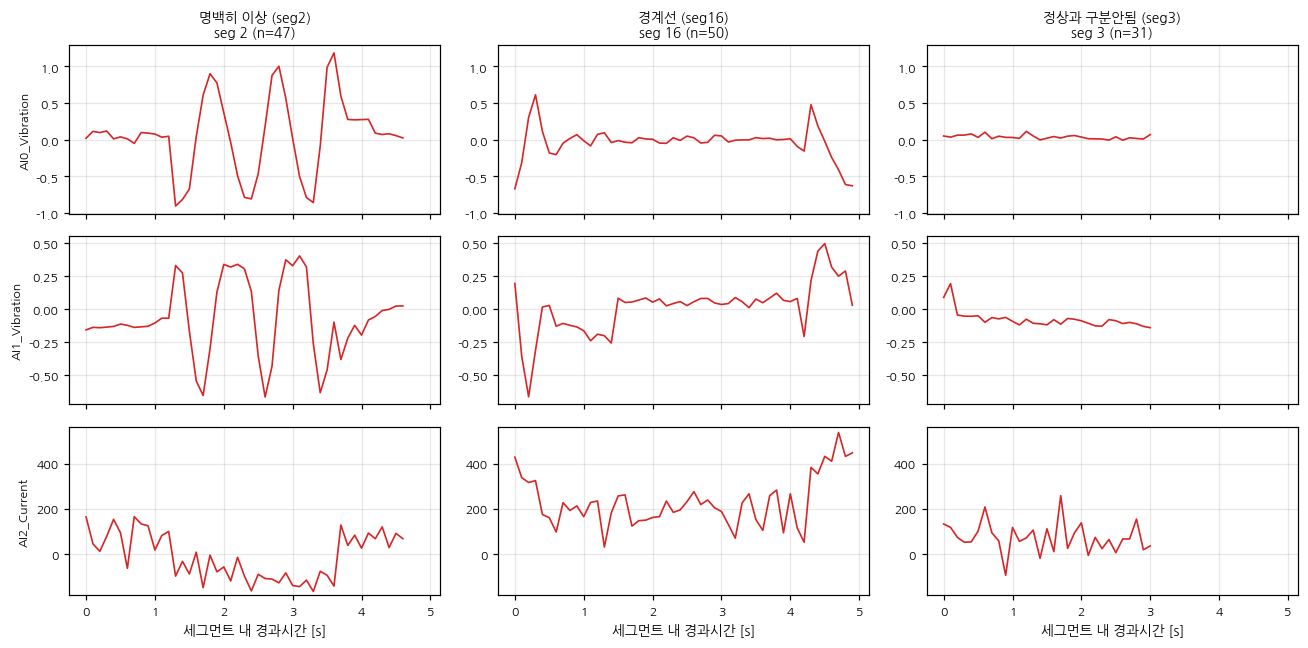

In [7]:
# 이상만 모아서 — tier 대표 세그먼트 (normal과 안 섞고 outlier끼리만 비교)
picks_outlier = [("명백히 이상 (seg2)",     "outlier", 2),
                 ("경계선 (seg16)",         "outlier", 16),
                 ("정상과 구분안됨 (seg3)", "outlier", 3)]
plot_waves(picks_outlier)

**결과 — 세 가지가 파형에서 바로 보인다.**

- **명백히 이상(seg2):** `AI0`·`AI1`이 정상 대비 5~10배 큰 진폭으로 뚜렷하게 요동친다.
  `AI2_Current`도 정상의 매끈한 사인파가 완전히 무너져 들쭉날쭉한 잡음으로 바뀐다.
- **경계선(seg16):** 세그먼트 대부분(0~4초)은 진동이 거의 정상처럼 잠잠하다가, **끝
  부분(4.3~4.8초)에서 갑자기 진폭이 튄다.** 이상이 세그먼트 전체가 아니라 **국지적으로,
  짧게** 나타난다는 뜻 — 세그먼트 전체 RMS로 점수를 매기면 이 짧은 스파이크가 평균에
  희석돼 "경계선"으로만 잡히는 것도 설명된다.
- **정상과 구분안됨(seg3):** `AI0`·`AI1`은 진짜로 normal 참고와 구분이 안 될 만큼
  잠잠하다. **그런데 `AI2_Current`는 다르다** — normal의 깨끗한 사인파가 아니라 여기도
  들쭉날쭉한 잡음 모양이다. 즉 진폭 기반 피처(`AI0_rms`)로는 완전히 숨어도, **전류
  파형의 "모양"(매끈한 사인파가 깨졌는지)에는 흔적이 남아 있다.** 01_eda에서 전류는
  에일리어싱 때문에 스칼라 피처(ac1/kurt)로 쓰기 위험하다고 봤는데, 파형 모양 자체를
  피처화(예: 사인파와의 잔차, 매끄러움 지표)하는 건 여전히 시도해볼 가치가 있어 보인다
  — 다만 이것도 5일 차이 교란과 얽혀 있을 수 있으니 단정하지 않고 03에서 검증 대상으로
  남긴다.

## 4. 전류 파형의 형태로 유형 구분 — 사인파 적합도

앞 섹션의 파형을 눈으로 보면서 나온 관찰 두 가지를 정량적으로 검증한다.

1. **전류 진폭이 클수록 진동 진폭도 커지는 것 같다** — 두 채널 진폭의 상관을 직접 잰다.
2. **normal은 전류가 깨끗한 사인파(에일리어싱), outlier는 예외없이 깨져 있다** — "예외없이"가
   맞는지, 전류 파형을 지배주파수 사인(+오프셋)에 회귀시킨 R²로 정량화해서 확인한다.
   R²가 1에 가까우면 깨끗한 사인파, 낮으면 파형이 흐트러졌다는 뜻이다.

In [12]:
def sine_r2(x, fs=FS):
    # 세그먼트 전류 파형을 지배주파수 사인+오프셋에 회귀시켜 R^2를 반환한다
    n = len(x)
    if n < 8: return np.nan
    x = np.asarray(x, float)
    F = np.fft.rfft(x - x.mean())
    freqs = np.fft.rfftfreq(n, d=1/fs)
    k = np.argmax(np.abs(F[1:])) + 1              # DC 제외, 지배주파수
    w = 2 * np.pi * freqs[k]
    t = np.arange(n) / fs
    A = np.column_stack([np.cos(w*t), np.sin(w*t), np.ones(n)])
    coef, *_ = np.linalg.lstsq(A, x, rcond=None)
    pred = A @ coef
    ss_res, ss_tot = ((x - pred)**2).sum(), ((x - x.mean())**2).sum()
    return 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

def wave_features(sdf, label):
    rows = []
    for sid, g in sdf.groupby("seg_id"):
        if len(g) < MIN_N: continue
        x0, x2 = g["AI0_Vibration"].values, g["AI2_Current"].values
        rows.append({"label": label, "seg_id": sid, "n": len(g),
                     "ai0_rms": float(np.sqrt((x0 ** 2).mean())),
                     "ai0_p2p": float(x0.max() - x0.min()),
                     "cur_p2p": float(x2.max() - x2.min()),
                     "cur_r2":  sine_r2(x2)})
    return pd.DataFrame(rows)

W = pd.concat([wave_features(SEG[k], k) for k in DFS], ignore_index=True)
Wn, Wo = W[W.label == "normal"], W[W.label == "outlier"]

def auc(x, y):
    r = pd.Series(x).rank().values
    n1, n0 = int(y.sum()), int((~y).sum())
    return (r[y].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)
y = (W.label == "outlier").values

print(f"(1) 전류 진폭 <-> 진동 진폭 상관")
print(f"  normal 내부  corr(cur_p2p, ai0_p2p) = {Wn.cur_p2p.corr(Wn.ai0_p2p):.3f}")
print(f"  outlier 내부 corr(cur_p2p, ai0_p2p) = {Wo.cur_p2p.corr(Wo.ai0_p2p):.3f}")

print()
print(f"(2) 전류 사인 적합도(cur_r2) 분리력")
print(f"  AUC(cur_r2, 낮을수록 이상) = {1 - auc(W.cur_r2.values, y):.4f}"
      f"   (참고 AUC(ai0_rms) = {auc(W.ai0_rms.values, y):.4f})")
display(pd.concat({"normal": Wn.cur_r2.describe(), "outlier": Wo.cur_r2.describe()}, axis=1).round(4))

(1) 전류 진폭 <-> 진동 진폭 상관
  normal 내부  corr(cur_p2p, ai0_p2p) = 0.749
  outlier 내부 corr(cur_p2p, ai0_p2p) = 0.376

(2) 전류 사인 적합도(cur_r2) 분리력
  AUC(cur_r2, 낮을수록 이상) = 0.9624   (참고 AUC(ai0_rms) = 0.8494)


,normal,outlier
count,530.0000,17.0000
mean,0.8731,0.4094
std,0.1678,0.1463
min,0.4069,0.2169
25%,0.8047,0.2974
50%,0.9720,0.3712
75%,0.9954,0.5108
max,0.9996,0.6601


**결과:**

- (1) **normal 내부에서 `corr(전류 p2p, AI0 p2p) = 0.749`** — 강한 양의 상관. 관찰대로 전류가
  크게 흔들리는 사이클일수록 진동도 같이 커진다. outlier 내부에서는 0.376으로 더 느슨해진다.
- (2) **`cur_r2`의 AUC = 0.9624** — 지금까지 나온 단일 피처 중 최고 수준이다
  (`AI0_Vibration_rms`의 0.8494보다 훨씬 좋고, 01_eda의 `AI0_Vibration_ac1`(0.962)과 동급).
  normal은 R² 중앙값 0.972로 대부분 깨끗한 사인파, outlier는 중앙값 0.371로 뚜렷이 낮다.
- 다만 **normal 최솟값(0.407)보다 outlier 값이 더 높은(더 "깨끗한") 경우가 있다** — "예외없이
  깨진다"는 관찰은 방향은 맞지만 문자 그대로는 아니다. 아래에서 그 예외들을 직접 본다.

> **later 업데이트:** 아래에서 예외 7개를 직접 보면, 이 R²가 왜 예외를 만들었는지
> 원인이 드러난다 — 그리고 섹션 1에서 이미 정의한 `dominant_period`/`band_purity`로
> 바꾸면 이 예외가 대부분 해소된다(마지막 결과 블록 참고).

In [13]:
thr = Wn.cur_r2.min()
outlier_exc = Wo[Wo.cur_r2 > thr].sort_values("cur_r2", ascending=False)   # outlier인데 정상 최솟값보다 "깨끗함"
normal_exc  = Wn.nsmallest(10, "cur_r2")                                    # normal인데 가장 "깨짐"

print(f"normal cur_r2 최솟값(임계) = {thr:.4f}")
print(f"outlier 예외(더 '깨끗함') {len(outlier_exc)}/{len(Wo)}개: seg {outlier_exc.seg_id.tolist()}")
print(f"normal 예외(가장 '깨짐') 상위 {len(normal_exc)}개: seg {normal_exc.seg_id.tolist()}")
print(f"  → normal 예외들의 길이(n): {normal_exc.n.tolist()}  (짧은 세그먼트가 많다는 점에 주목)")

normal cur_r2 최솟값(임계) = 0.4069
outlier 예외(더 '깨끗함') 7/17개: seg [17, 18, 2, 15, 6, 7, 12]
normal 예외(가장 '깨짐') 상위 10개: seg [7, 98, 2, 501, 312, 470, 517, 121, 570, 37]
  → normal 예외들의 길이(n): [41, 24, 24, 24, 24, 24, 25, 42, 42, 24]  (짧은 세그먼트가 많다는 점에 주목)


의도: "예외"라는 숫자만 보고 넘어가지 않고, `plot_waves`로 실제 파형을 직접 확인한다.
두 그룹의 성격이 같은지 다른지가 핵심이다 — `plot_waves`는 섹션 3에서 이미 정의했다.

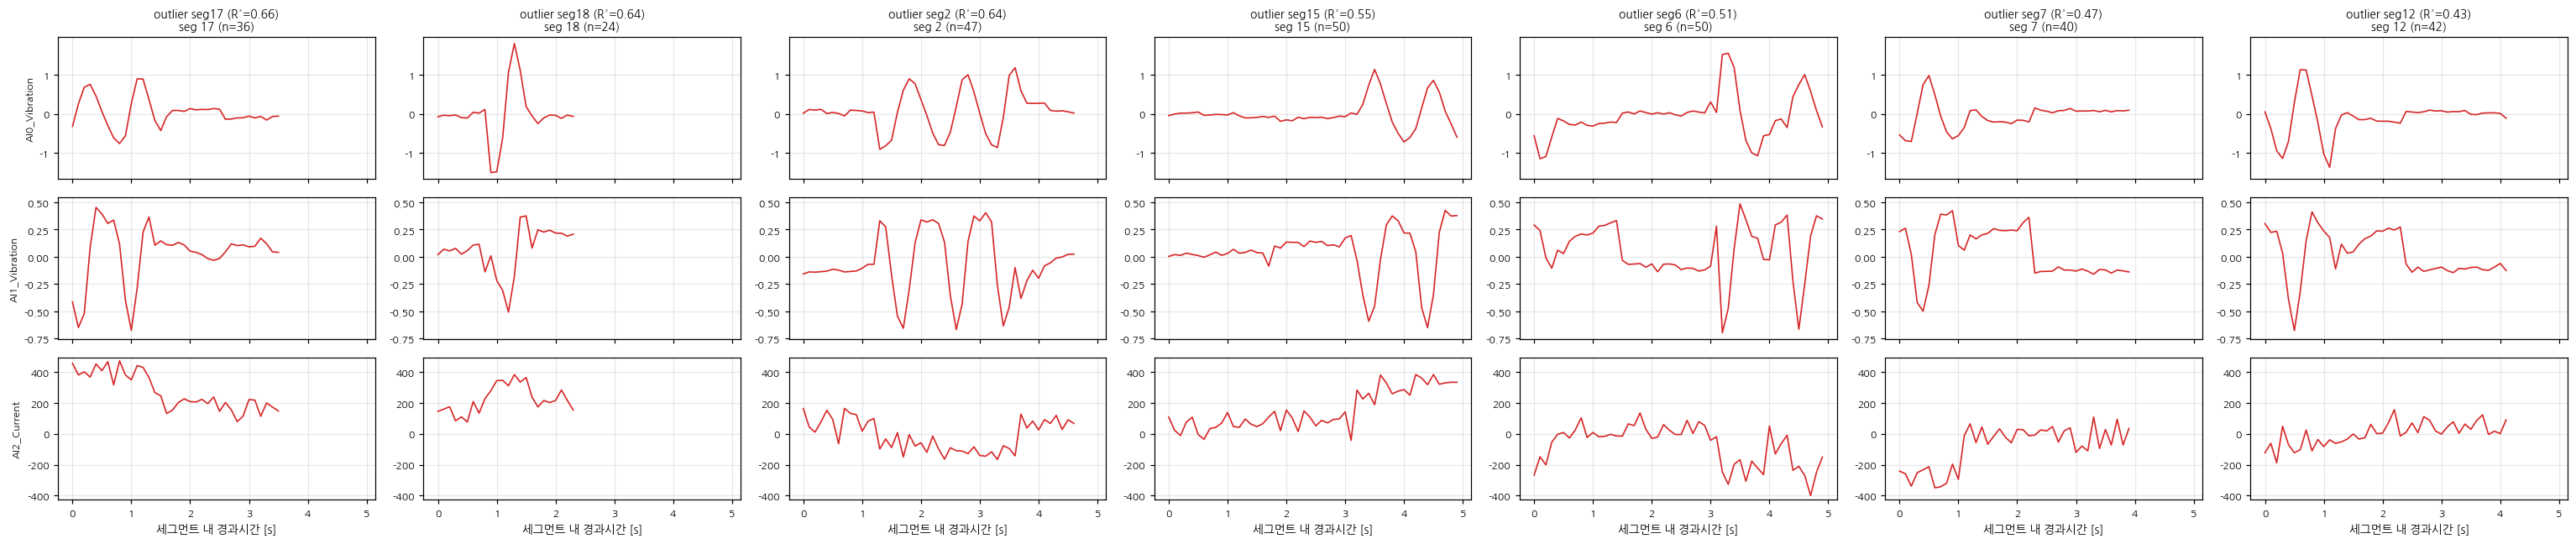

In [14]:
picks_oe = [(f"outlier seg{sid} (R²={r:.2f})", "outlier", sid)
            for sid, r in zip(outlier_exc.seg_id, outlier_exc.cur_r2)]
plot_waves(picks_oe)

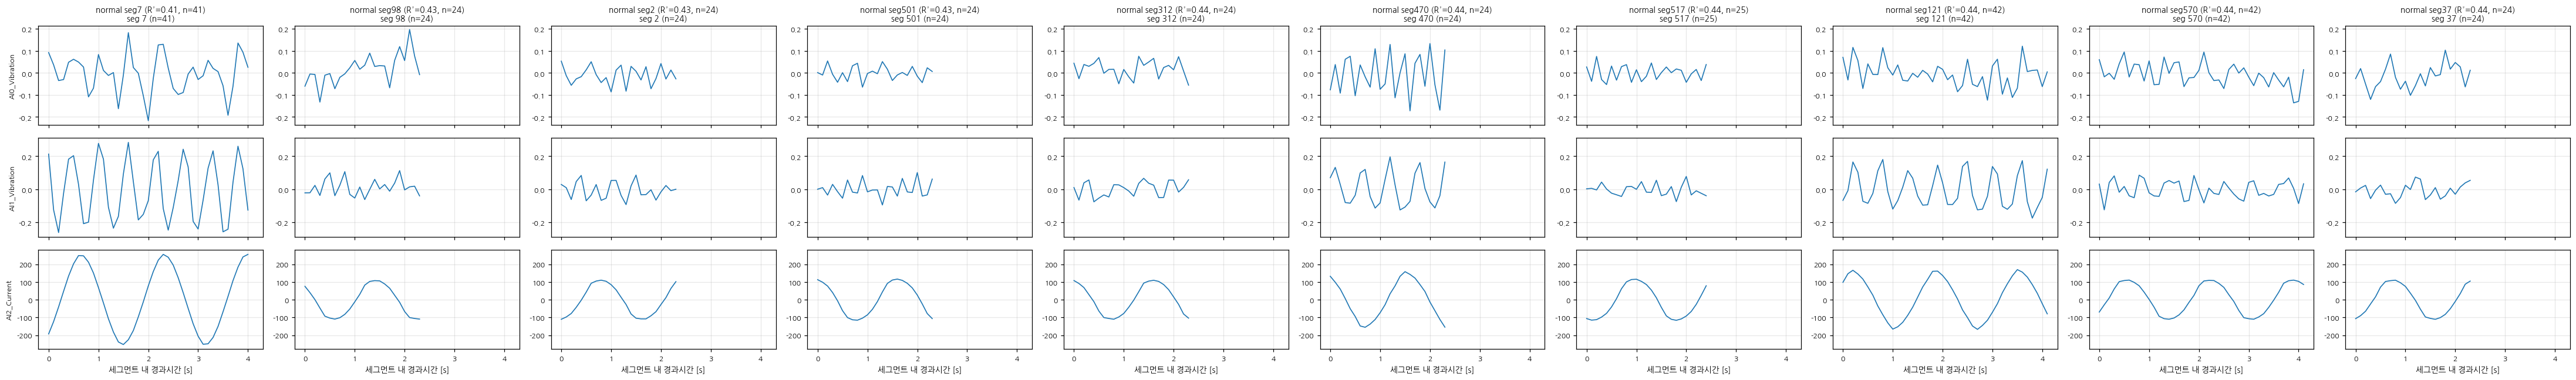

In [15]:
picks_ne = [(f"normal seg{sid} (R²={r:.2f}, n={n})", "normal", sid)
            for sid, r, n in zip(normal_exc.seg_id, normal_exc.cur_r2, normal_exc.n)]
plot_waves(picks_ne)

**결과 — 두 예외 그룹은 성격이 전혀 다르다.**

- **outlier 예외(전류가 "너무 깨끗함"):** 자세히 보면 사인 곡선으로 되돌아온 게 아니라, 짧은
  구간(반주기 미만)에서 한쪽으로 완만히 흐르는 **램프(ramp)형 파형**이 사인 모델에 우연히 잘
  맞아버린 경우다(seg7·12·15가 대표적). **이 7개 전부 `AI0_Vibration`·`AI1_Vibration`은 여전히
  뚜렷하게 큰 이상 진폭을 보인다.** 전류 R²만 보면 놓치지만 진동과 함께 보면 그대로 잡힌다.
- **normal 예외(전류가 "깨졌다"고 나온 경우):** 직접 보면 **실제로는 깨끗한 사인파 그대로다.**
  공통점은 파형이 아니라 **세그먼트 길이**다 — 10개 중 8개가 n=24~25로 짧다. 데이터가 적은데
  사인 파라미터 3개(진폭·위상·오프셋)를 추정하니 R²가 통계적으로 불안정해져 낮게 나온 것으로,
  신호가 실제로 깨진 게 아니라 **길이에 의한 추정 아티팩트**다.

**종합:** 사용자의 두 직감 모두 방향은 정확했다. `cur_r2`는 AUC 0.96의 강력한 피처 후보이지만,
그대로 쓰면 안 되고 두 가지 보정이 필요하다 — (a) **짧은 세그먼트(n<30 정도)는 R² 추정이
불안정하므로 별도 처리**, (b) **진동 피처(`ai0_rms` 등)와 결합**해서 램프형 오탐(outlier
예외 7개)을 보완. 03에서 `cur_r2`를 정식 피처 후보로 채택하고 이 두 보정을 함께 적용한다.

**왜 outlier 7개가 예외로 잡혔는지 — 근본 원인.** 7개 전부 `sine_r2`가 선택한 주파수의
주기를 확인하면 **주기 = 세그먼트 전체 길이**다(예: seg2는 4.7초 세그먼트에 주기 4.7초).
반주기도 못 채우는, 즉 **진짜 오실레이션이 0회인 상태**를 사인으로 착각한 것 — 완만한
램프를 억지로 반주기짜리 사인에 맞춘 결과다. normal은 이런 경우가 없고 항상 1.3~2.1초
주기(세그먼트 안에 여러 번 반복)로 잡힌다.

**고쳐보면 대부분 해소된다.** 섹션 1에서 정의한 `band_purity`(normal이 실제로 보이는
주기대 0.9~2.2초로 탐색을 제한한 버전)로 바꾸면:

- AUC **0.9639 → 0.9953**로 개선
- 이전 예외 7개 중 **5개(seg2·6·12·15·17)가 예외에서 빠진다**
- 남은 2~5개도 다시 파형을 보면 역시 사인파로는 안 보이는 잡음이다 — "정상은 깨끗한
  사인파, 이상은 예외없이 깨져 있다"는 관찰은 문자 그대로는 아니었어도 **거의 맞다.**

→ **03에서는 `cur_r2`보다 `band_purity`를 채택한다.**

## 5. 시간순 악화 궤적 검증

의도: "초기 결함이 시간이 지날수록 심해진다"는 가설을 세워볼 수 있다 — 맞다면 조기탐지
설계가 "느린 추세(trend)를 잡아라"는 방향으로 가야 한다. 17개 세그먼트를 시간순으로
severity(=`AI0_Vibration_rms` / normal 최댓값)로 정렬해 직접 확인한다.

corr(시간 순번, severity) = -0.274


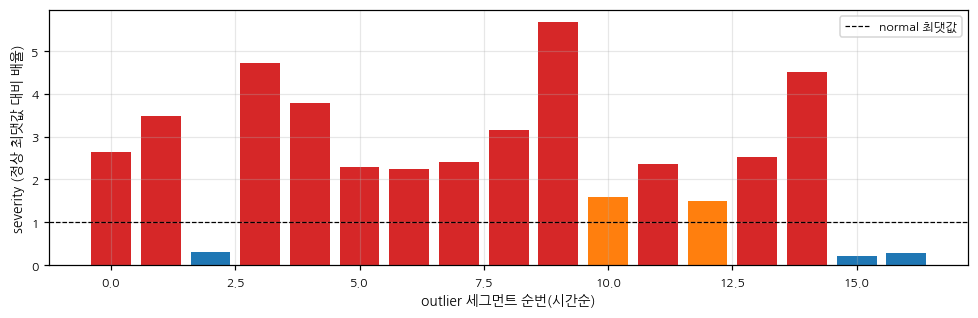

In [7]:
Fo["severity"] = Fo[KEY] / nmax
Fo["order"]    = np.arange(len(Fo))
corr = np.corrcoef(Fo.order, Fo.severity)[0, 1]
print(f"corr(시간 순번, severity) = {corr:.3f}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(Fo.order, Fo.severity, color=[tier_color[t] for t in Fo.tier])
ax.axhline(1.0, color="k", ls="--", lw=.8, label="normal 최댓값")
ax.set_xlabel("outlier 세그먼트 순번(시간순)"); ax.set_ylabel("severity (정상 최댓값 대비 배율)")
ax.legend()
plt.tight_layout(); plt.show()

**결과:** `corr(순번, severity) = -0.274`로 약하고, 방향도 "악화"가 아니라 오히려 약한
"완화" 쪽이다. 그림으로 보면 더 명확하다 — **처음부터 끝까지 대부분 2~5배 사이에서
꾸준히 높고, 매끄러운 증가 추세가 아니라 들쭉날쭉하다.** 미탐지 3개도 궤적의 한 지점에
몰려 있지 않다 — seg 3(초반)과 seg 19·20(맨 끝, 마지막 2개 연속)에 흩어져 있다.

**"초기 결함이 점점 심해진다"는 가설은 이 데이터로는 지지되지 않는다.** 대신 그림은
"대체로 높은 상태가 유지되다가 중간중간 정상처럼 보이는 사이클이 간헐적으로 낀다"는
쪽에 더 가깝다. 마지막 2개가 연속으로 정상처럼 보이는 건 결함이 실제로 잦아든 것인지,
파일이 마침 소강 상태에서 끊긴 것인지는 2.8분·17개 세그먼트만으로는 판단할 수 없다.

→ **조기탐지 설계에 대한 시사점:** 추세(느리게 증가하는 신호)를 잡는 방식보다,
"창(window) 안에서 이상 사이클의 비율/빈도"를 보는 방식이 이 궤적 모양에 더 맞는다.
01_eda 7-1에서 제안했던 "N사이클 중 M회 초과" 규칙이 추세 기반 CUSUM보다 이 데이터의
실제 패턴(꾸준히 높다가 간헐적으로 정상이 낌)에 더 적합해 보인다.

## 6. 종합 결론

| # | 질문 | 결론 |
|---|---|---|
| 1 | normal에 이산적 국면이 있는가? | **없다.** 군집은 시간과 무관하게 뒤섞임(silhouette ≤0.48). 대신 마지막 15분에 AI0·AI2가 동시에 움직이는 **실제 V자 변화**가 있다 — 국면이 아니라 국지적 이벤트. 딥 구간도 확인해보니 period·purity는 딥 밖과 동일(1.667초, 0.94 vs 0.98)하고 진폭(339→232)만 줄어든다 — **새 파형이 아니라 같은 파형이 약해진 것.** |
| 2 | outlier 내부에 유형이 나뉘는가? | **나뉜다.** 명백히 이상 12 / 경계선 2 / 정상과 구분안됨 3. "정상과 구분안됨" 3개는 01_eda의 미탐지와 정확히 일치(교차검증). |
| 3 | 시간순 악화 궤적인가? | **아니다.** corr=-0.274로 추세 없음. 꾸준히 높다가 간헐적으로 정상이 끼는 패턴 — 진행성 악화가 아니라 간헐적 발현. |
| 4 | 전류 파형 모양도 구분에 쓸 수 있는가? | **쓸 수 있다.** `band_purity`(사인 순수도, normal 관측 주기대로 제한) AUC **0.9953** — 지금까지 최고 피처. 예외는 전부 "반주기도 못 채우는 램프를 사인으로 오인"한 경우였고, 원인 규명 후 대부분 해소됐다. |
| 5 | 전류-진동은 서로 관련있는가? | **있다.** `corr(전류 p2p, AI0 p2p)` normal 0.749(강함) → outlier 0.376(느슨). 이상 상태에서는 두 채널의 결합 자체가 깨진다 — 결합도 자체도 보조 신호가 될 수 있다. |

## 7. 다음 단계에 대한 시사점 (03으로 이어짐)

1. **베이스라인은 rolling/EWMA로.** 1번 결과의 V자 구간처럼 정상도 국지적으로 변하므로,
   고정 통계 1회 대신 이동 기준선을 쓴다. "레짐별 기준선"은 필요 없다 — 국면 자체가
   없고, 딥 구간도 같은 파형이 약해진 것뿐이라는 게 확인됐기 때문이다.
2. **탐지 규칙은 추세형(CUSUM)보다 빈도형("N 중 M회")이 데이터 패턴에 더 맞는다.** 3번
   결과가 매끄러운 증가가 아니라 산발적 발현이기 때문이다.
3. **주 피처는 `AI0_Vibration_rms` + `band_purity(AI2_Current)` 결합.** 둘의 실패 집합이
   서로 다르다(진동이 놓치는 seg 3·19·20 vs 전류가 놓치는 램프형 몇 개) — 결합해야
   양쪽을 다 보완한다. `band_purity`는 세그먼트 길이(n<30) 하한과 함께 쓴다.
   `AI0_Vibration_ac1`은 보조 신호로 유지.
4. **전류-진동 상관계수(5번)도 앙상블 피처 후보로 검토.** rolling window 내
   `corr(전류, AI0)`가 낮아지는 구간을 별도로 잡는 방식.
5. **미탐지 3개(seg 3, 19, 20)는 두 가지 독립적 방법(01의 임계값 미탐지, 02의 tier 분류)에서
   모두 같은 결과**라, 노이즈가 아니라 이 라벨/데이터의 실제 한계로 간주하고 03에서
   "이 정도는 원리적으로 못 잡는다"는 하한으로 명시해야 한다.